## Statistical Profiling

This notebook aims to present the key findings from data cleaning and preliminary statistical studies performed using SQL, it also presents a more detailed statistical description of the data using histograms and boxplots.

### General description of data

In [2]:
import pandas as pd
from sqlalchemy import create_engine
from local_settings import postgres_url as url
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load 'milling_pdm_celsius' dataset to a pandas dataframe and show
url = f"postgresql+psycopg2://{url['pguser']}:{url['pgpassword']}@{url['pghost']}/{url['pgdb']}"
engine = create_engine(url)
df = pd.read_sql(f"SELECT * FROM milling_pdm_celsius",con=engine, index_col="register_id")
df

,product_id,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,tool_wear_failure,heat_dissipation_failure,power_failure,overstrain_failure,random_failure
register_id,,,,,,,,,,,,,
1,M14860,M,24.950006,35.450006,1551.0,42.8,0,False,False,False,False,False,False
2,L47181,L,25.050012,35.550012,1408.0,46.3,3,False,False,False,False,False,False
3,L47182,L,24.950006,35.350000,1498.0,49.4,5,False,False,False,False,False,False
4,L47183,L,25.050012,35.450006,1433.0,39.5,7,False,False,False,False,False,False
5,L47184,L,25.050012,35.550012,1408.0,40.0,9,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,M24855,M,25.649988,35.249994,1604.0,29.5,14,False,False,False,False,False,False
9997,H39410,H,25.749994,35.249994,1632.0,31.8,17,False,False,False,False,False,False
9998,M24857,M,25.850000,35.450006,1645.0,33.4,22,False,False,False,False,False,False


In [34]:
# Load 'failure_data_unpivoted' dataset to a pandas dataframe and show
df_failure_mode = pd.read_sql(f"SELECT * FROM failure_data_unpivoted",con=engine, index_col="register_id")
df_failure_mode

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,machine_failure,status
register_id,,,,,,,
1,M,24.950006,35.450006,1551.0,42.8,False,NORMAL
2,L,25.050012,35.550012,1408.0,46.3,False,NORMAL
3,L,24.950006,35.350000,1498.0,49.4,False,NORMAL
4,L,25.050012,35.450006,1433.0,39.5,False,NORMAL
5,L,25.050012,35.550012,1408.0,40.0,False,NORMAL
...,...,...,...,...,...,...,...
9996,M,25.649988,35.249994,1604.0,29.5,False,NORMAL
9997,H,25.749994,35.249994,1632.0,31.8,False,NORMAL
9998,M,25.850000,35.450006,1645.0,33.4,False,NORMAL


In [4]:
# Show all collumns in the database
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   product_id                   10000 non-null  str    
 1   product_type                 10000 non-null  str    
 2   air_temperature_celsius      10000 non-null  float64
 3   process_temperature_celsius  10000 non-null  float64
 4   rotational_speed_rpm         10000 non-null  float64
 5   torque_nm                    10000 non-null  float64
 6   tool_wear_min                10000 non-null  int64  
 7   machine_failure              10000 non-null  bool   
 8   tool_wear_failure            10000 non-null  bool   
 9   heat_dissipation_failure     10000 non-null  bool   
 10  power_failure                10000 non-null  bool   
 11  overstrain_failure           10000 non-null  bool   
 12  random_failure               10000 non-null  bool   
dtypes: bool(6), float64(4), int

### Data Quality Analysis (DQA)

Data quality analysis was performed using SQL and resulted in the following conclusions:

- There are no duplicates in the data
- There are no NULL values in the data
- All products ID conforms to the rule: Letter H/M/L followed by 5 digit integer
- All product types are either H, M or L
- All measured temperatures are greater than zero Kelvin
- Rotational speeds and torques were registered in absolute values
- No data aquisition point presented negative values for wear time counter (tool_wear_min)

Which indicates that no major quality issue was identified.

On the other hand, investigation of the failure events shows that there are 9 aquisition points where a machine failure was reported, but the failure wasn't classified into one of the main failure modes listed. This event corresponds to less than 3% of the reported machine failures, so it shouldn't interefere with the statistical studies and failure mode analysis to be presented.

### Summary of basic statistical metrics

Preliminary studies of basic statistical metrics were performed in SQL for both categorical and continous data. In the following cells the key results are presented:

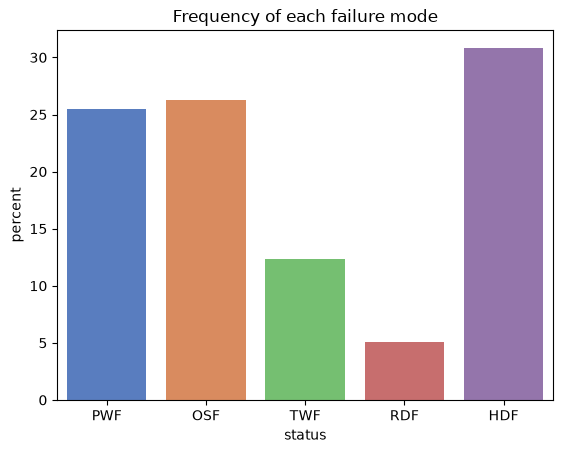

In [38]:
# Countplot of failure modes
sns.countplot(data=df_failure_mode[df_failure_mode["status"]!="NORMAL"], x='status', hue='status', palette='muted', stat='percent', legend=False)
plt.title('Frequency of each failure mode')
plt.show()

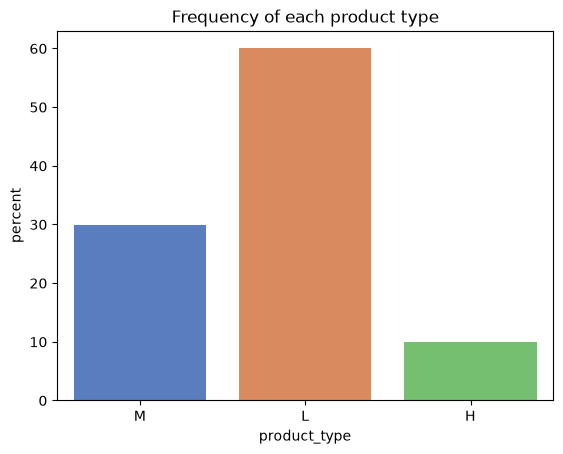

In [6]:
# Countplot of product types
sns.countplot(data=df, x='product_type', hue='product_type', palette='muted', stat='percent', legend=False)
plt.title('Frequency of each product type')
plt.show()

#### Categorical data

- Most machined products were of the Low Quality (L) type making up to 60% of the data
- As expected machine failures is a rare event in comparison to the overall operation of the machine: they correspond only to 3.4% of the aquisition points
- Interaction between failure modes were observed, but the isolated modes make up approximately 90% of the failures indicating that the combinations are rare.
- The most common combination of failure modes is PWF + OSF which represents 3% of the failures
- The most frequent failure mode is HDF with 32.2% of representation, including its combinations
- Tool failure represents only 12.9% of the failure data, including its combinations (more commonly associated with OSF)

In [7]:
df.describe()

,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,tool_wear_min
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,26.854930,36.855560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,22.149988,32.550012,1168.000000,3.800000,0.000000
25%,25.149988,35.649988,1423.000000,33.200000,53.000000
50%,26.950006,36.950006,1503.000000,40.100000,108.000000
75%,28.350000,37.950006,1612.000000,46.800000,162.000000
max,31.350000,40.649988,2886.000000,76.600000,253.000000


#### Continuous data

Statistical summary of the continuous collumns shows that:

- Rotational speed and torque shows a range much greater than the 4*IQR interval
- Other collumns show median and mean values close to each other, range inside the 4*IQR interval and apparently symmetrical distribution as indicated by the difference between P75 or P25 and the median.

### Raw numerical data boxplots

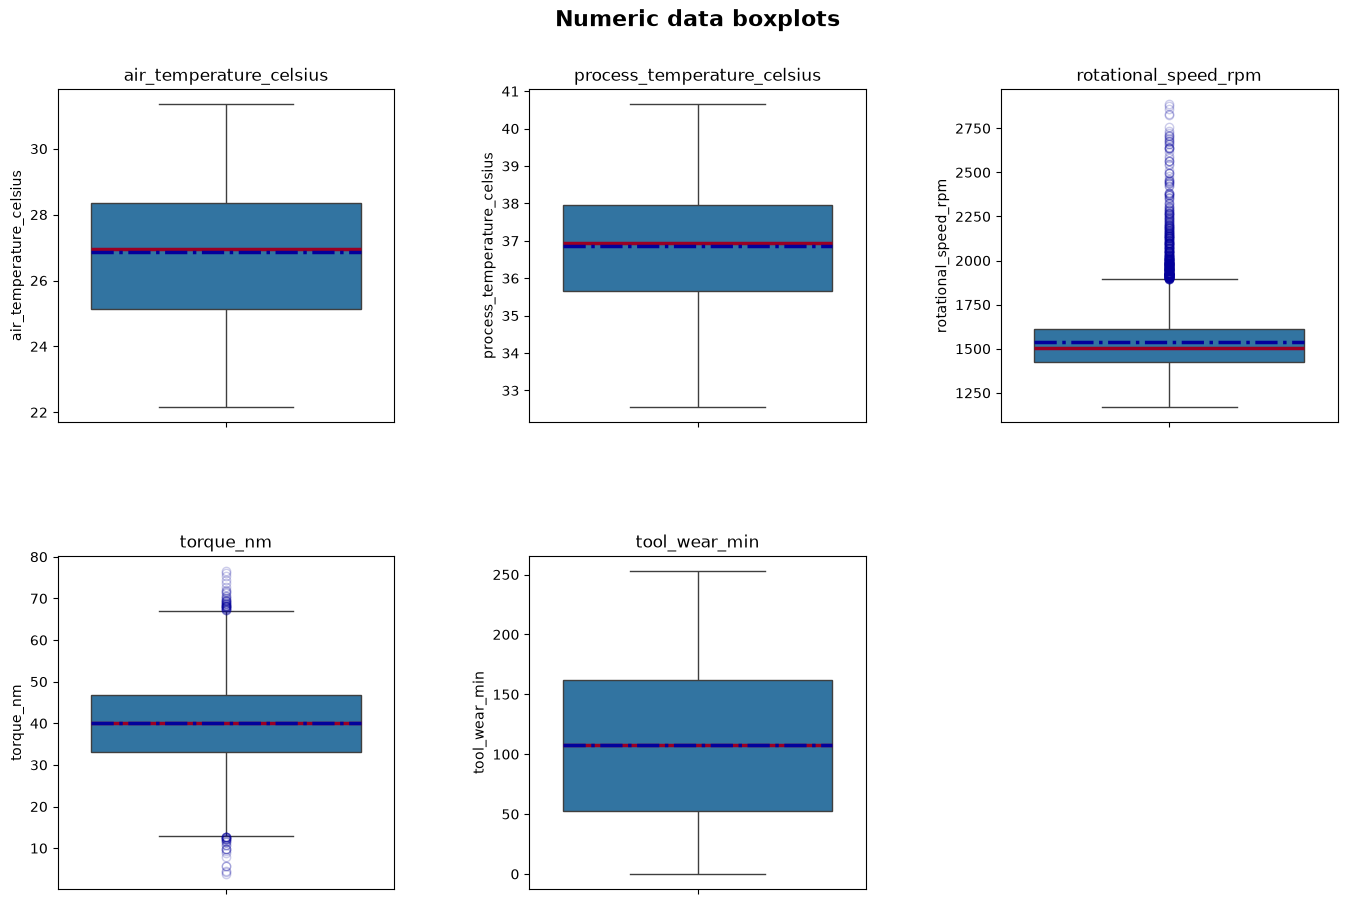

In [8]:
# Study of distributions of numerical data (boxplots)
layout = [
    ["air_temperature_celsius", "process_temperature_celsius", "rotational_speed_rpm"],
    ["torque_nm", "tool_wear_min", '.']
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(16,10));
fig.suptitle('Numeric data boxplots', fontsize=16, fontweight='bold')
# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.boxplot(data=df,
                y=name,
                showmeans=True,
                meanline=True,
                #boxprops={"facecolor": "#9ED0FF"},
                medianprops={"color": "#9B0022", "linewidth": 2.5},
                meanprops={"color": "#03009B", "linewidth": 2.5, "linestyle": "-."},
                flierprops={"marker": "o", "markeredgecolor": "#03009B", "alpha": 0.2},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

# plt.savefig("boxplots.png")

- The boxplots confirms that that air temperature, process temperature and tool wear collumns are well behaved with all data inside the 4*IQR interval and median approximately equals to the mean
- Rotational speed has a lot of outliers above the upper limit
- Torque has a lot of outliers concentrated both above the upper limit and bellow the lower limit

Further investigation of rotational speed and torque is required

### Raw numerical data distributions

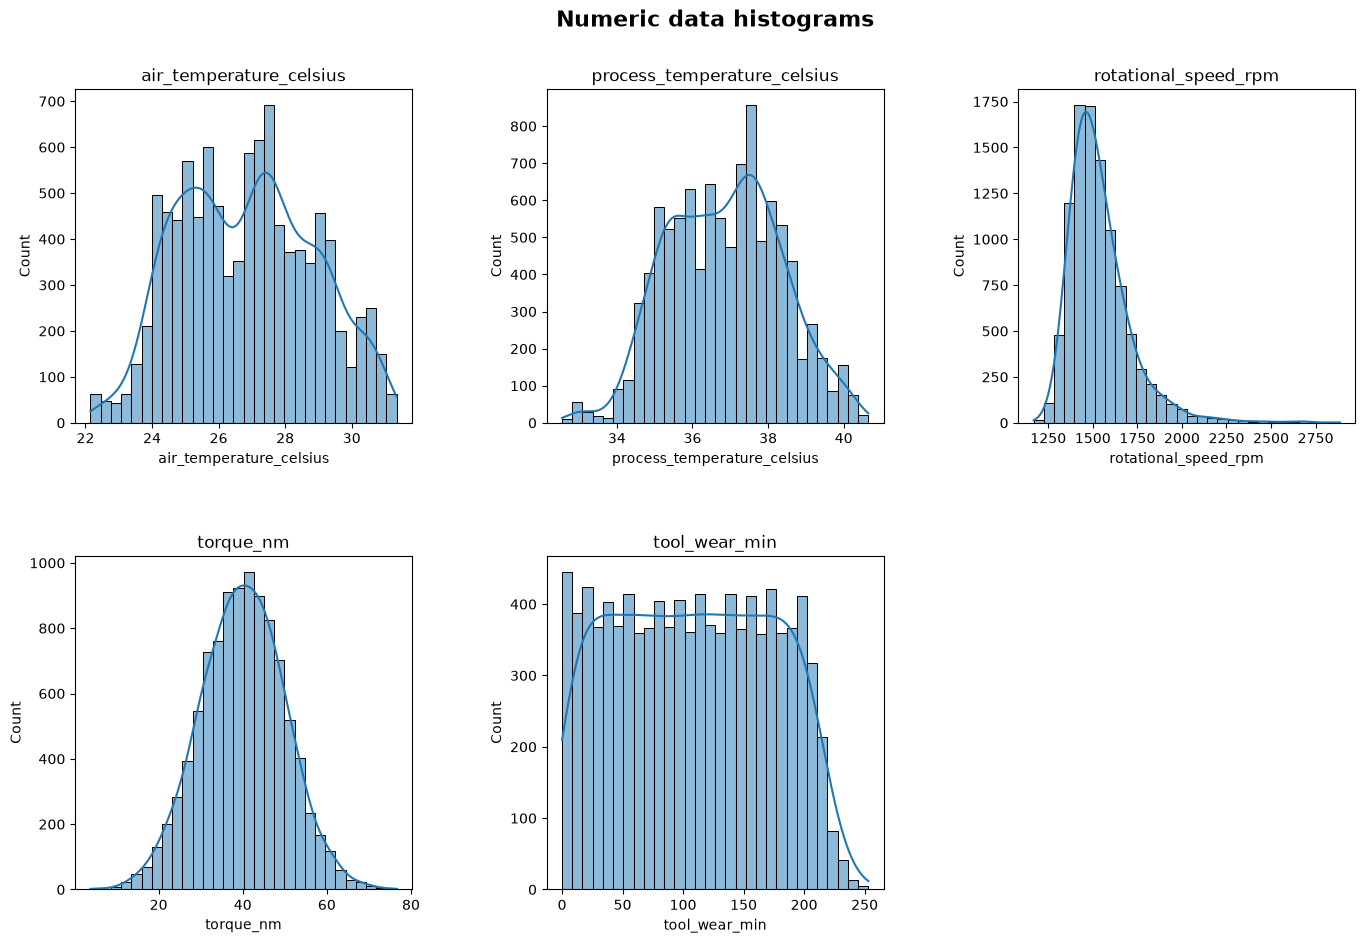

In [ ]:
# Study of distributions of numerical data (histograms)

layout = [
    ["air_temperature_celsius", "process_temperature_celsius", "rotational_speed_rpm"],
    ["torque_nm", "tool_wear_min", '.']
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(16,10));
fig.suptitle('Numeric data histograms', fontsize=16, fontweight='bold')

# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.histplot(data=df,
                #stat="density",
                #common_norm=False,
                x=name,
                #hue="machine_failure",
                bins = 30,
                kde=True,
                kde_kws={"bw_adjust":1.5},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

#lt.savefig("histplots.png")

- Even though air temperature showed signs of symmetrical distribution by analysing its basical central tendency and variability metrics, the histogram shows a very disturbed distribution with apparently 4 peaks of different heights, which could be associated with different operational regimes
- Process temperature also showed a non-symmetric distribution with apparently two peaks
- Rotational speed histogram shows an unimodal normal distribution with a heavy tail to the right
- Torque histogram shows an unimodal symmetrical normal distribution
- Tool wear column, as expected for a time counter, shows a uniform distribution of values that vanishes arround 225 minutes of wear.

Further investigation of air and process temperature is required for identifying multimodal behaviour.

### Statistical behaviour under failure

In [39]:
df_failure_mode

,product_type,air_temperature_celsius,process_temperature_celsius,rotational_speed_rpm,torque_nm,machine_failure,status
register_id,,,,,,,
1,M,24.950006,35.450006,1551.0,42.8,False,NORMAL
2,L,25.050012,35.550012,1408.0,46.3,False,NORMAL
3,L,24.950006,35.350000,1498.0,49.4,False,NORMAL
4,L,25.050012,35.450006,1433.0,39.5,False,NORMAL
5,L,25.050012,35.550012,1408.0,40.0,False,NORMAL
...,...,...,...,...,...,...,...
9996,M,25.649988,35.249994,1604.0,29.5,False,NORMAL
9997,H,25.749994,35.249994,1632.0,31.8,False,NORMAL
9998,M,25.850000,35.450006,1645.0,33.4,False,NORMAL


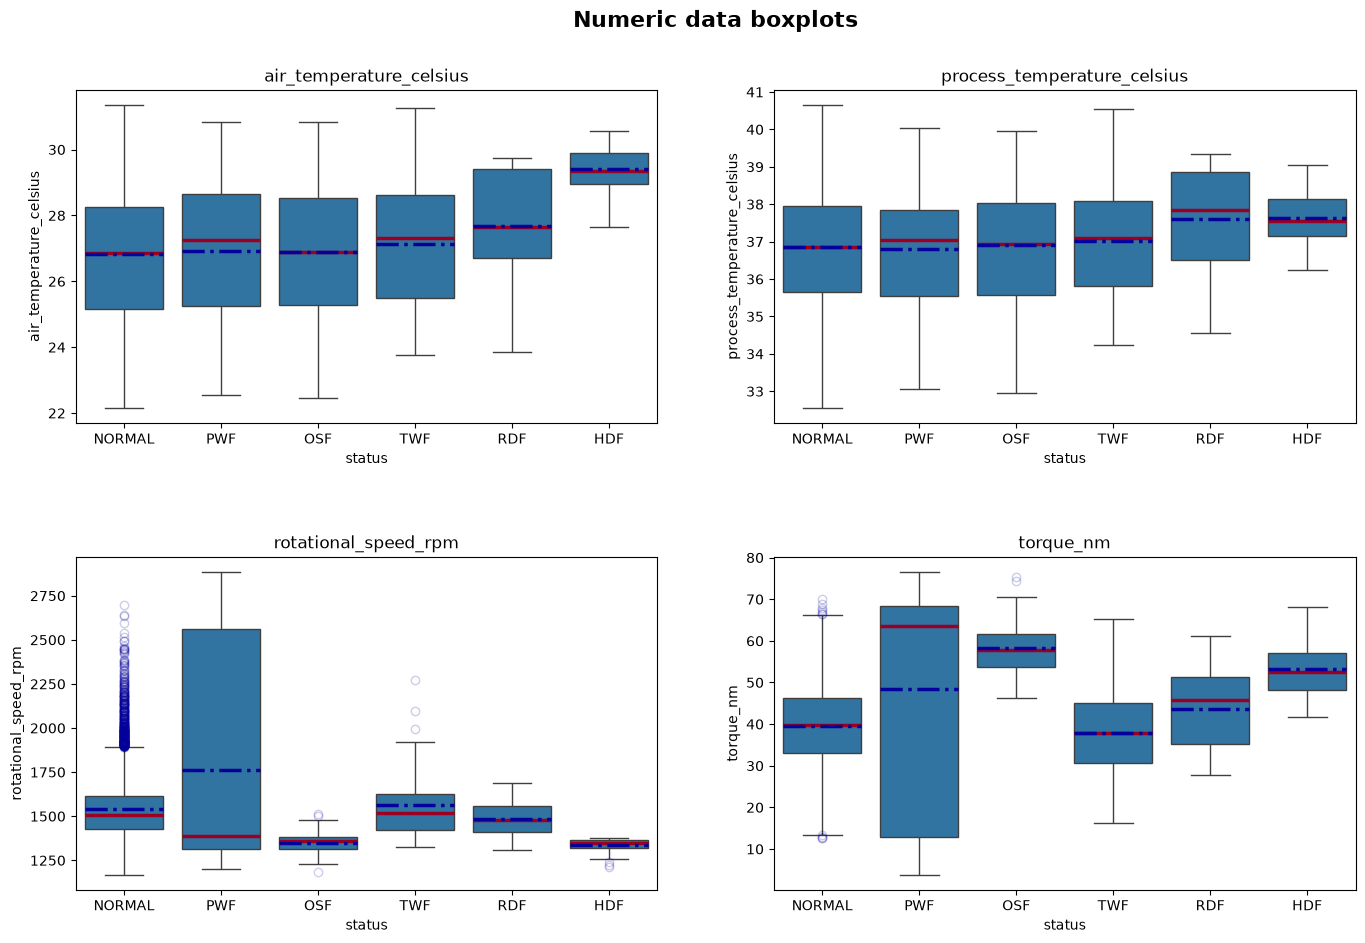

In [41]:
# Study of distributions of numerical data (boxplots)
layout = [
    ["air_temperature_celsius", "process_temperature_celsius"],
    ["rotational_speed_rpm", "torque_nm"]
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(16,10));
fig.suptitle('Numeric data boxplots', fontsize=16, fontweight='bold')
# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.2,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.boxplot(data=df_failure_mode,
                y=name,
                x='status',
                #hue="product_type",
                showmeans=True,
                meanline=True,
                #boxprops={"facecolor": "#9ED0FF"},
                medianprops={"color": "#9B0022", "linewidth": 2.5},
                meanprops={"color": "#03009B", "linewidth": 2.5, "linestyle": "-."},
                flierprops={"marker": "o", "markeredgecolor": "#03009B", "alpha": 0.2},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

# plt.savefig("boxplots.png")

- At HDF conditions, air temperature has a median and average greater than in normal operation conditions, other failure conditions exhibit similar location and variability to the normal operation
- At PWF conditions both rotational speed and torque shows a very high variability and large distances between average and median, with the rotational speed average smaller than the median and toque median bigger than its median.
- OSF and HDF conditions show a very narrow  rotational speed variability with some outliers
- OSF shows torque values higher than normal operation as shown by the higher median / average values
- Note that RDF events are rare in comparison to the other failure modes (only 5% of the failure events), so their statistical metrics have high uncertainty

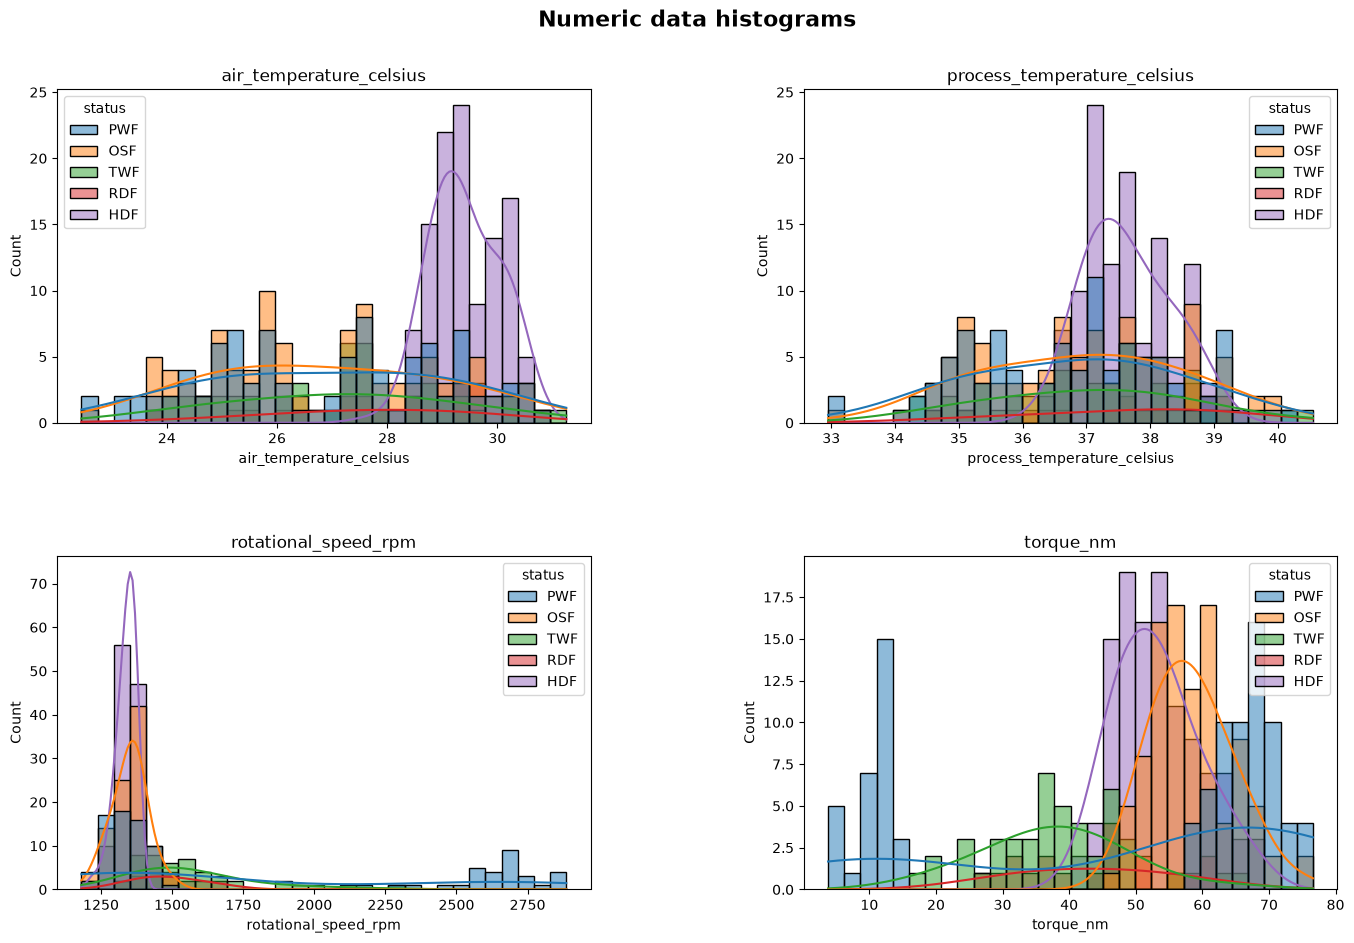

In [45]:
# Study of distributions of numerical data (histograms)

layout = [
    ["air_temperature_celsius", "process_temperature_celsius", ],
    ["rotational_speed_rpm" , "torque_nm"]
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(16,10));
fig.suptitle('Numeric data histograms', fontsize=16, fontweight='bold')

# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.histplot(data=df_failure_mode[df_failure_mode["status"]!="NORMAL"],
                #stat="density",
                #common_norm=False,
                x=name,
                hue="status",
                bins = 30,
                kde=True,
                kde_kws={"bw_adjust":1.5},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

- Air temperature histogram by failure mode shows a clear shift of the HDF distribution to the right, confirming that heat dissipation issues are associated with an increase in room temperature
- Rotational speed distributions at HDF and OSF are shifted to the left in comparison to normal operation conditions, while torque distributions at HDF and OSF are shifted to the right. If machine available power is the same during the operation, low rotational speeds could be associated with higher torques a condition that is prone to overstrain failures.

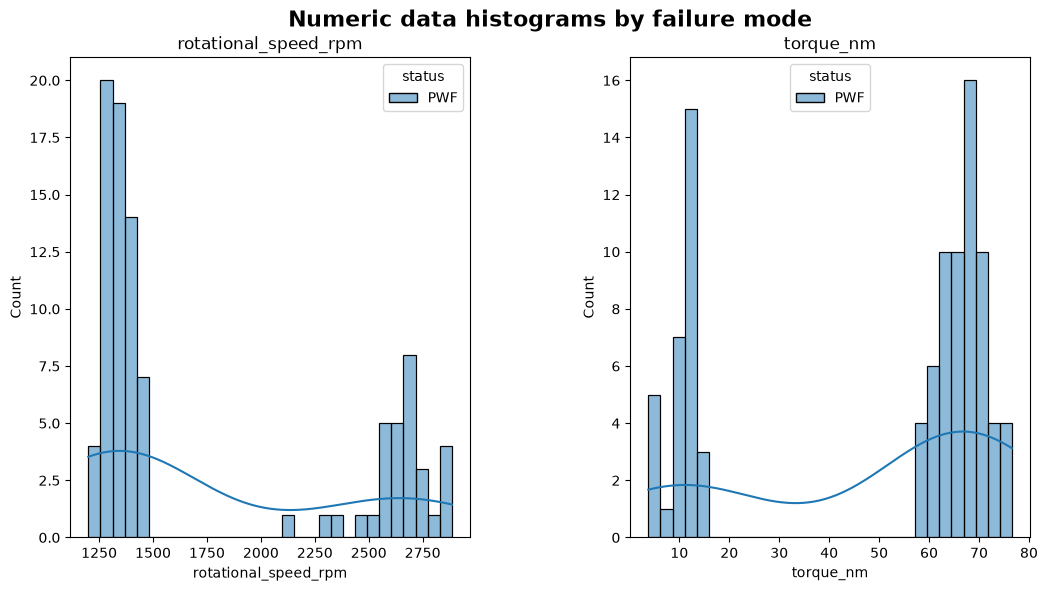

In [62]:
# Study of distributions of numerical data (histograms)

layout = [
    ["rotational_speed_rpm", "torque_nm"]
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(12,6));
fig.suptitle('Numeric data histograms by failure mode', fontsize=16, fontweight='bold')

# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.8     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.histplot(data=df_failure_mode[df_failure_mode["status"]=="PWF"],
                #stat="density",
                #common_norm=False,
                x=name,
                hue="status",
                bins = 30,
                kde=True,
                kde_kws={"bw_adjust":1.5},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

- Rotational speed and torque at PWF conditions exhibts a bimodal distribution that could be associated with two cenarios of high enough mechanical power to cause a failure: high velocities + low torque or high torque + low velocites.

<Axes: xlabel='register_id'>

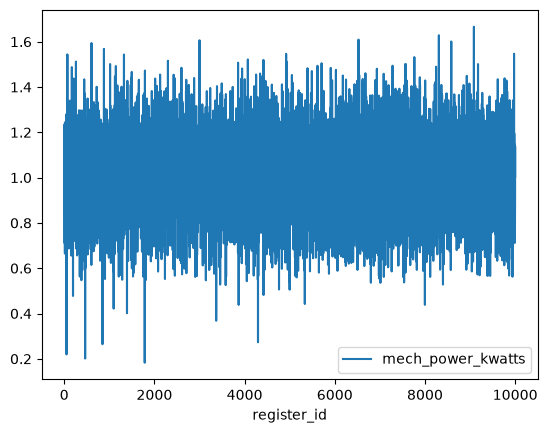

In [77]:
# Convert rotational speed to hertz (1/s)
df_failure_mode["rotational_speed_hz"] = df_failure_mode["rotational_speed_rpm"] / 60
# Create a column for mechanical power in kW
df_failure_mode["mech_power_kwatts"] = (df_failure_mode["rotational_speed_hz"] * df_failure_mode["torque_nm"])/1000
df_failure_mode.plot(y="mech_power_kwatts")

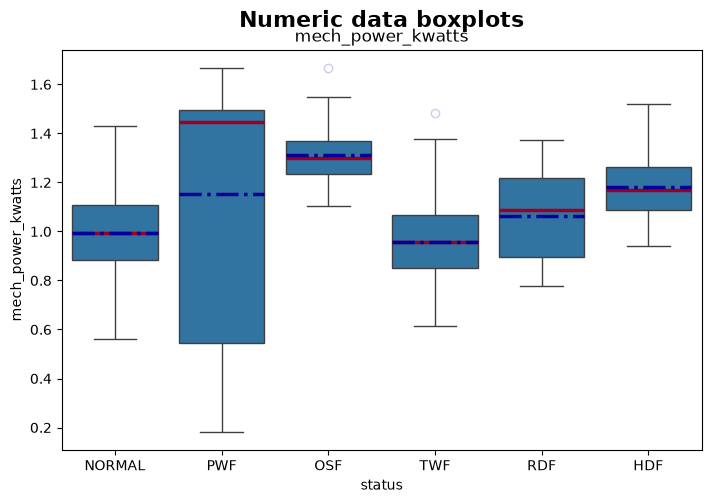

In [76]:
# Study of distributions of numerical data (boxplots)
layout = [
    ["mech_power_kwatts"]
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(8,5));
fig.suptitle('Numeric data boxplots', fontsize=16, fontweight='bold')
# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.2,    # Width padding between subplots (fraction of axes width)
    hspace=0.4     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.boxplot(data=df_failure_mode,
                y=name,
                x='status',
                #hue="product_type",
                showmeans=True,
                meanline=True,
                #boxprops={"facecolor": "#9ED0FF"},
                medianprops={"color": "#9B0022", "linewidth": 2.5},
                meanprops={"color": "#03009B", "linewidth": 2.5, "linestyle": "-."},
                flierprops={"marker": "o", "markeredgecolor": "#03009B", "alpha": 0.2},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

# plt.savefig("boxplots.png")

- The machine normal operation shows mechanical average and median very close to 1 kW, while in PWF, OSF, RDF and HDF conditions the median / average is shifted to higher values

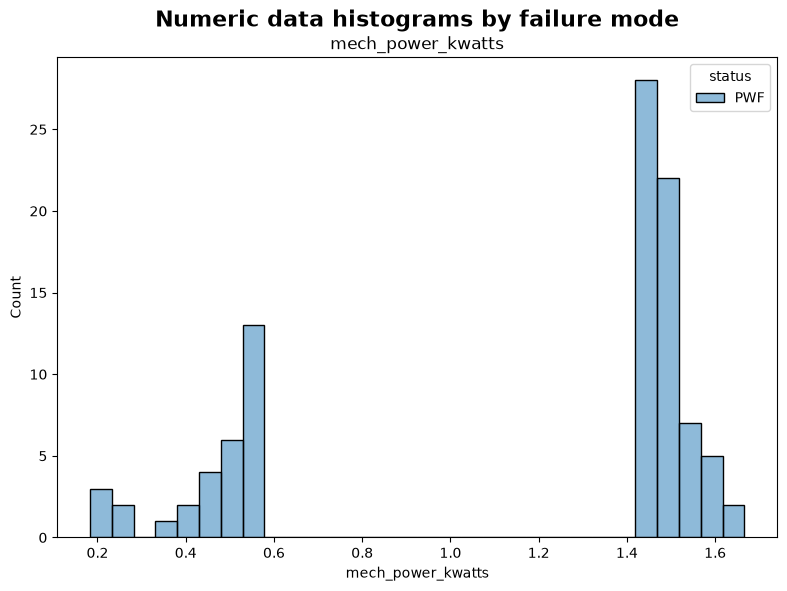

In [82]:
# Study of distributions of numerical data (histograms)
layout = [
    ["mech_power_kwatts"]
]
fig, ax_dict = plt.subplot_mosaic(layout, figsize=(9,6));
fig.suptitle('Numeric data histograms by failure mode', fontsize=16, fontweight='bold')

# Adjust spacing between plots and page margins
plt.subplots_adjust(
    left=0.1,      # Left margin (fraction of figure width)
    right=0.9,     # Right margin
    bottom=0.1,    # Bottom margin (fraction of figure height)
    top=0.9,       # Top margin
    wspace=0.4,    # Width padding between subplots (fraction of axes width)
    hspace=0.8     # Height padding between subplots (fraction of axes height)
)

for i, name in enumerate(ax_dict.keys(), 1):
    sns.histplot(data=df_failure_mode[df_failure_mode["status"]=="PWF"],
                #stat="density",
                #common_norm=False,
                x=name,
                hue="status",
                bins = 30,
                kde=False,
                kde_kws={"bw_adjust":1.5},
                ax=ax_dict[name])
    ax_dict[name].set_title(name)

- Mechanical power histogram shows a bimodal distribution, wich isn't coherent with the initial hypothesis of two cenarios of high/low rotational speed and torque that produces the same high mechanical power causing PWF. Further investigation of what is being considered as a Power Failure and decomposing power issues in electrical supply, mechanical and engine over heating should be considered.


## Conclusion

- No major data quality issues where identified, just some data points missing failure cause definition
- Most of the failures are related to heat dissipation issues and, even though the company shows a special concern with the increase in tool replacements, the percentage of failures caused by tool wear make up only approximately 12% of the total reported failure modes.
- In the analysed period most of the machined products were of the Low Quality representing 60% of the production
- Irregular distribution of air and process temperatures could be associated with different operating regimes or sensor issues, further investigation of the causes of temperature oscilations should be made
- As initially expected, an increase in air temperature at heat dissipation failure events could be observed by its distribution
- Rotational speed and torque distributions at failure events shows an inverted relation with each other: most of the rotational speed peaks are located at the low values, while the torque peaks at the high values for all failure modes
- Rotational speed and torque distribution at power failure events exhibits a bimodal behaviour, wich initially was associated with two ways of achieving the same mechanical power required for causing the failure, but after calculating the power and investigating its distribution, the same bimodal behaviour was observed at power failure condition indicating that failure is not related to a single and well defined limit on power value.